In [ ]:
# see https://github.com/mmaelicke/scikit-gstat/tree/main/tutorials for details on using skgstat package

In [15]:
### set up the notebook
import skgstat as skg
import matplotlib.pyplot as plt
import numpy as np

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
np.set_printoptions(linewidth=100) 

plt.rcParams.update({'font.size': 14})


/tmp/ipykernel_3996145/3439655052.py:6: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [16]:
### load the GNSS, ACCESS, and ERA5 model data for each site

GNSS = np.genfromtxt('../data_to_publish/buoy_hourly_WPD.csv', delimiter=",")
ACCESS = np.genfromtxt('../data_to_publish/ACCESS_hourly_WPD.csv', delimiter=",")
SWOT = np.genfromtxt('../data_to_publish/ECMWF_FSP_WPD.csv', delimiter=",")

coords = np.genfromtxt('../data_to_publish/buoy_locations_FSP_UTM.csv', delimiter=",")

In [18]:
### discard times without complete data (i.e. we want nine data points for every variogram, consistent between GNSS and ACCESS)

# print shape
print("Shape of datasets before NaN removal: GNSS %s, ACCESS %s" % (np.shape(GNSS), np.shape(ACCESS)))

# print number of nans in each
print("Number of NaNs in each dataset: GNSS %s, ACCESS %s" % (len(GNSS[np.isnan(GNSS)]), len(ACCESS[np.isnan(ACCESS)])))

GNSS_full = []
ACCESS_full = []


for i in range(len(GNSS[0,:])):
    gnss_row = GNSS[:,i]
    access_row = ACCESS[:,i]
    
    if len(gnss_row[np.isnan(gnss_row)]) == 0:
        if len(access_row[np.isnan(access_row)]) == 0:
            GNSS_full.append(gnss_row)
            ACCESS_full.append(access_row)
                
GNSS_full = np.array(GNSS_full)
ACCESS_full = np.array(ACCESS_full)

# print shape
print("\nShape of datasets after NaN removal: GNSS %s, ACCESS %s" % ((np.shape(GNSS_full), np.shape(ACCESS_full))))

# print number of nans in each
print("Check there are now zero nans: GNSS %s, ACCESS %s" % (len(GNSS_full[np.isnan(GNSS_full)]), len(ACCESS_full[np.isnan(ACCESS_full)])))    

Shape of datasets before NaN removal: GNSS (9, 2184), ACCESS (9, 2184)
Number of NaNs in each dataset: GNSS 1767, ACCESS 1593

Shape of datasets after NaN removal: GNSS (1264, 9), ACCESS (1264, 9)
Check there are now zero nans: GNSS 0, ACCESS 0


In [19]:
### repeat for SWOT 

# print shape
print("Shape of datasets before NaN removal: SWOT ", np.shape(SWOT))

# print number of nans in each
print("Number of NaNs in each dataset: SWOT ", (len(SWOT[np.isnan(SWOT)])))

SWOT_full = []

for i in range(len(SWOT[0,:])):
    swot_row = SWOT[:,i]
        
    if len(swot_row[np.isnan(swot_row)]) == 0:
        SWOT_full.append(swot_row)
            
SWOT_full = np.array(SWOT_full)

# print shape
print("\nShape of datasets after NaN removal: SWOT ", (np.shape(SWOT_full)))

# print number of nans in each
print("Check there are now zero nans: SWOT ", (len(SWOT_full[np.isnan(SWOT_full)])))

Shape of datasets before NaN removal: SWOT  (9, 96)
Number of NaNs in each dataset: SWOT  18

Shape of datasets after NaN removal: SWOT  (94, 9)
Check there are now zero nans: SWOT  0


In [20]:
### calculate semivariograms GNSS and ACCESS

empirical_list_GNSS = []
empirical_list_ACCESS = []

n_lags = 8

for i in range(np.shape(GNSS_full)[0]):
    try:
        GNSS_vals = GNSS_full[i, :]
        ACCESS_vals = ACCESS_full[i, :]
        
        GNSS_V = skg.Variogram(coords, GNSS_vals, n_lags=n_lags, normalize=False)
        ACCESS_V = skg.Variogram(coords, ACCESS_vals, n_lags=n_lags, normalize=False)
    
        empirical_list_GNSS.append(GNSS_V.get_empirical()[1])
        empirical_list_ACCESS.append(ACCESS_V.get_empirical()[1])
    
    except:
        print('skipping ', i)
        continue

lag_list = GNSS_V.get_empirical()[0]

empirical_GNSS = np.array(empirical_list_GNSS)
empirical_ACCESS = np.array(empirical_list_ACCESS)

empirical_GNSS_mean = np.mean(empirical_GNSS, axis=0)
empirical_ACCESS_mean = np.mean(empirical_ACCESS, axis=0)


In [21]:
### calculate semivariograms ECMWF

empirical_list_SWOT = []

n_lags = 8

for i in range(np.shape(SWOT_full)[0]):
    try:
        SWOT_vals = SWOT_full[i, :]
        SWOT_V = skg.Variogram(coords, SWOT_vals, n_lags=n_lags, normalize=False)
        empirical_list_SWOT.append(SWOT_V.get_empirical()[1])
    
    except:
        print('skipping ', i)
        continue

lag_list_SWOT = SWOT_V.get_empirical()[0]

empirical_SWOT = np.array(empirical_list_SWOT)
empirical_SWOT_mean = np.mean(empirical_SWOT, axis=0)

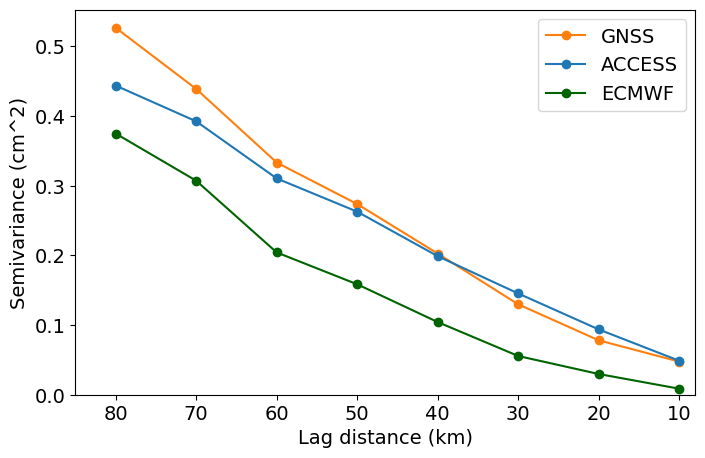

In [23]:
# plot the average variogram

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(lag_list/1000, empirical_GNSS_mean, c='C1', marker='o', label='GNSS')
ax.plot(lag_list/1000, empirical_ACCESS_mean, c='C0', marker='o', label='ACCESS')
ax.plot(lag_list_SWOT/1000, empirical_SWOT_mean, c='darkgreen', marker='o', label='ECMWF')
ax.set_xlabel('Lag distance (km)')
ax.set_ylabel('Semivariance (cm^2)')
ax.set_ylim(0,None)
ax.set_xlim(85,8)
ax.legend()
plt.show()


In [24]:
# Save data to .npz file
np.savez('/data/hendreya/troposphere/data_for_plots/semivariogram_data_ecmwf.npz', 
         lag_list=lag_list, 
         empirical_SWOT_mean=empirical_SWOT_mean)